In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load files
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.shape)
print(trades.shape)

display(sentiment.head())
display(trades.head())

(2644, 4)
(211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [121]:
def audit(df, name):
    print(f"\n{name}")
    print("="*50)

    print("Shape:", df.shape)

    print("\nMissing Values")
    print(df.isna().sum())

    print("\nDuplicates")
    print(df.duplicated().sum())

audit(sentiment, "Sentiment Data")
audit(trades, "Trader Data")


Sentiment Data
Shape: (2644, 4)

Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates
0

Trader Data
Shape: (211224, 16)

Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates
0


In [122]:
# Sentiment timestamps
sentiment["timestamp"] = pd.to_numeric(sentiment["timestamp"],errors="coerce")
sentiment["date"] = pd.to_datetime(sentiment["timestamp"],unit="s").dt.date

# Trader timestamps
trades["Timestamp"] = pd.to_numeric(trades["Timestamp"],errors="coerce")
trades["date"] = pd.to_datetime(trades["Timestamp"],unit="ms").dt.date

In [123]:
sentiment["classification"] = (sentiment["classification"].astype(str).str.strip())
print(sentiment["classification"].value_counts())

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [124]:
merged = trades.merge(sentiment[["date", "classification", "value"]],on="date",how="left")
print(merged.shape)
merged.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed,74.0


In [125]:
merged["Size USD"] = pd.to_numeric(merged["Size USD"],errors="coerce")
merged["Size Tokens"] = pd.to_numeric(merged["Size Tokens"],errors="coerce")
merged["Closed PnL"] = pd.to_numeric(merged["Closed PnL"],errors="coerce")
merged["Direction"] = (merged["Direction"].astype(str).str.upper())
merged["is_long"] = (merged["Direction"]=="BUY").astype(int)
merged["Execution Price"] = pd.to_numeric(merged["Execution Price"],errors="coerce")
merged["Start Position"] = pd.to_numeric(merged["Start Position"],errors="coerce")
merged["leverage_proxy"] = (merged["Size USD"] /merged["Start Position"].replace(0, np.nan))
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value,is_long,leverage_proxy
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,BUY,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed,74.0,1,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,BUY,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed,74.0,1,0.129424
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,BUY,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed,74.0,1,1.147739
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,BUY,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed,74.0,1,0.996059
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,BUY,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed,74.0,1,0.054091


In [126]:
daily_pnl = (merged.groupby("date").agg(daily_pnl=("Closed PnL", "sum"),trades=("Account", "count")).reset_index())
daily_pnl.head()

,date,daily_pnl,trades
0,2023-03-28,0.000000e+00,3
1,2023-11-14,1.555034e+02,1045
2,2024-03-09,1.769655e+05,6962
3,2024-07-03,1.587424e+05,7141
4,2024-10-27,3.189461e+06,35241


In [127]:
merged["win"] = (merged["Closed PnL"] > 0).astype(int)
daily_winrate = (merged.groupby("date").agg(win_rate=("win", "mean")).reset_index())
daily_winrate.head()

,date,win_rate
0,2023-03-28,0.000000
1,2023-11-14,0.274641
2,2024-03-09,0.490089
3,2024-07-03,0.317182
4,2024-10-27,0.451605


In [128]:
daily_trade_size = (merged.groupby("date").agg(avg_trade_size=("Size USD", "mean")).reset_index())
daily_trade_size.head()

,date,avg_trade_size
0,2023-03-28,159.000000
1,2023-11-14,11057.827522
2,2024-03-09,5660.265764
3,2024-07-03,3058.848110
4,2024-10-27,2949.625864


In [129]:
ls_ratio = (merged.groupby("date").agg(long_ratio=("is_long", "mean")).reset_index())
ls_ratio.head()

,date,long_ratio
0,2023-03-28,0.000000
1,2023-11-14,0.000000
2,2024-03-09,0.012640
3,2024-07-03,0.110069
4,2024-10-27,0.164751


In [130]:
merged["leverage_proxy"] = (merged["Size USD"] /merged["Start Position"].replace(0, np.nan))
merged["leverage_proxy"] = (merged["leverage_proxy"].replace([np.inf, -np.inf], np.nan))
merged["leverage_proxy"].describe()

count    2.071390e+05
mean     6.227092e+05
std      1.896448e+08
min     -1.045050e+10
25%     -3.109050e-02
50%      1.127323e-02
75%      4.985745e-01
max      7.696000e+10
Name: leverage_proxy, dtype: float64

In [131]:
sentiment_stats = (merged.groupby("classification").agg(
        pnl=("Closed PnL","mean"),
        win_rate=("win","mean"),
        avg_trade_size=("Size USD","mean"),
        leverage=("leverage_proxy","mean"),
        trades=("Trade ID","count") ))
sentiment_stats

,pnl,win_rate,avg_trade_size,leverage,trades
classification,,,,,
Extreme Greed,25.418772,0.490089,5660.265764,-50610.094212,6962
Fear,50.047622,0.415146,5259.977837,967303.372914,133871
Greed,87.894859,0.446471,3182.883845,979.614337,36289
Neutral,22.229713,0.317182,3058.848110,-1126.545839,7141


In [132]:
def sentiment_group(x):
    x = str(x).lower()
    if "fear" in x:return "Fear"
    if "greed" in x:return "Greed"
    return "Neutral"
merged["sentiment_group"] = (merged["classification"].apply(sentiment_group))

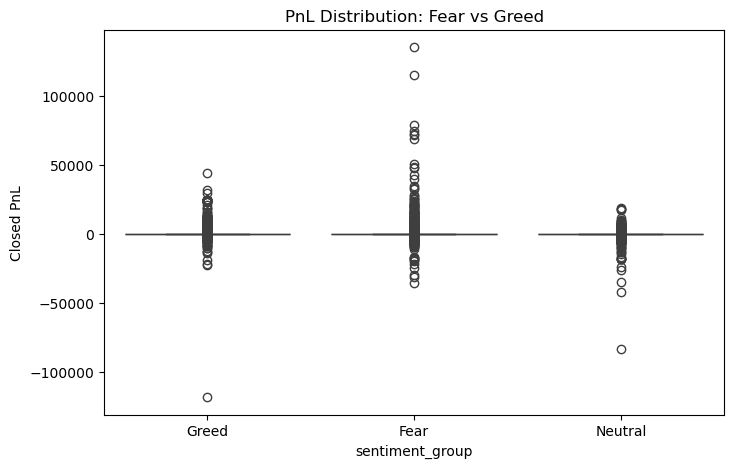

In [133]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged,x="sentiment_group",y="Closed PnL")
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

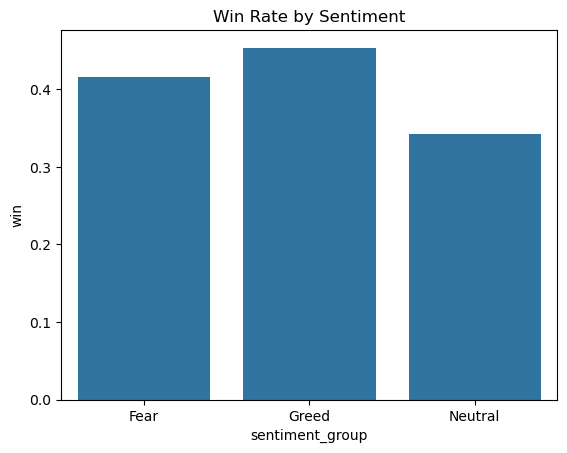

In [134]:
win_rate_by_sentiment = (merged.groupby("sentiment_group")["win"].mean().reset_index())
sns.barplot(data=win_rate_by_sentiment,x="sentiment_group",y="win")
plt.title("Win Rate by Sentiment")
plt.show()

In [135]:
account_pnl = (merged.groupby(["Account","date"])["Closed PnL"].sum().reset_index())
account_pnl["cum_pnl"] = (account_pnl.groupby("Account")["Closed PnL"].cumsum())
account_pnl["peak"] = (account_pnl.groupby("Account")["cum_pnl"].cummax())
account_pnl["drawdown"] = (account_pnl["cum_pnl"] -account_pnl["peak"])

account_pnl = account_pnl.merge(sentiment[["date","classification"]],on="date",how="left")

In [173]:
def sentiment_group(x):
    x = str(x).lower()

    if "fear" in x:
        return "Fear"

    elif "greed" in x:
        return "Greed"

    else:
        return "Neutral"

account_pnl["sentiment_group"] = (
    account_pnl["classification"]
    .apply(sentiment_group)
)

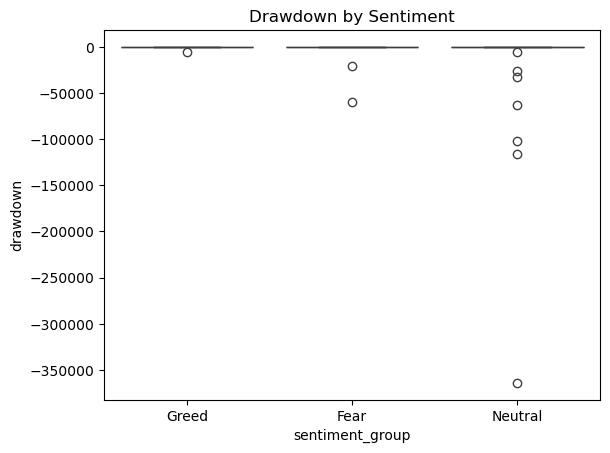

In [175]:
drawdown_stats = (account_pnl.groupby("sentiment_group")["drawdown"].mean().reset_index())
sns.boxplot(data=account_pnl,x="sentiment_group",y="drawdown")
plt.title("Drawdown by Sentiment")
plt.show()

In [177]:
drawdown_stats = (
    account_pnl.groupby("sentiment_group")
    .agg(
        avg_drawdown=("drawdown","mean"),
        median_drawdown=("drawdown","median"),
        min_drawdown=("drawdown","min")
    )
)

drawdown_stats

,avg_drawdown,median_drawdown,min_drawdown
sentiment_group,,,
Fear,-2496.129364,0.0,-59349.677108
Greed,-150.378815,0.0,-5564.016140
Neutral,-21518.207269,0.0,-363924.917628


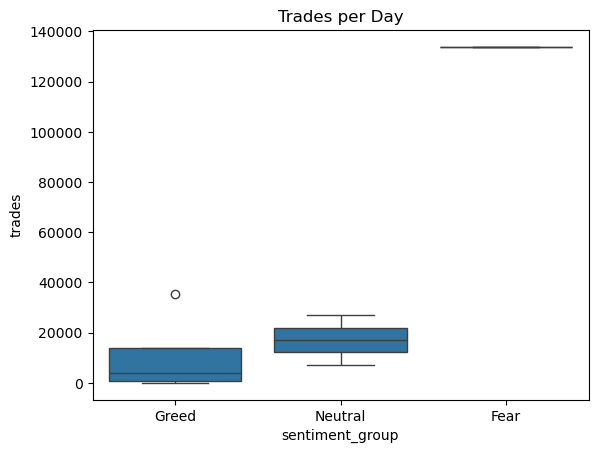

In [137]:
trade_freq = (merged.groupby(["date","sentiment_group"]).size().reset_index(name="trades"))
sns.boxplot(data=trade_freq,x="sentiment_group",y="trades")
plt.title("Trades per Day")
plt.show()

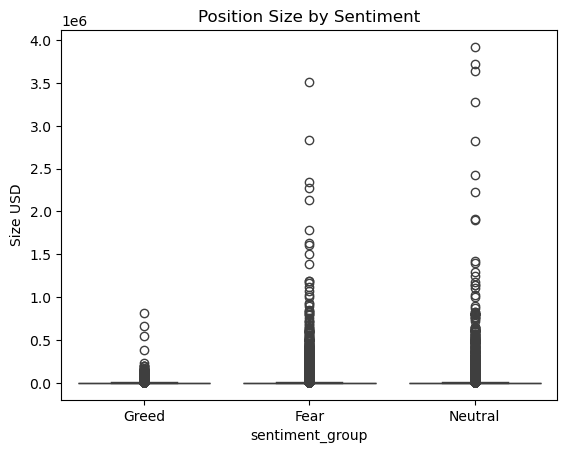

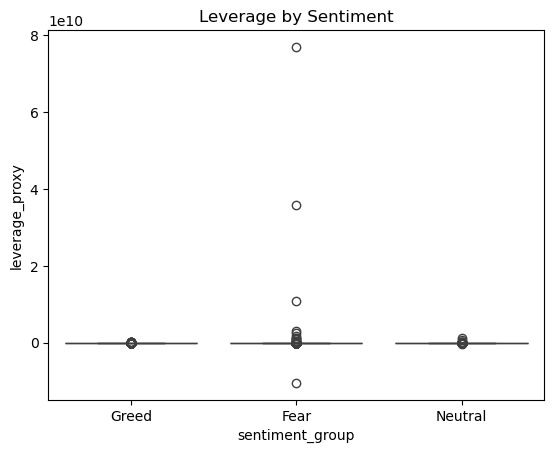

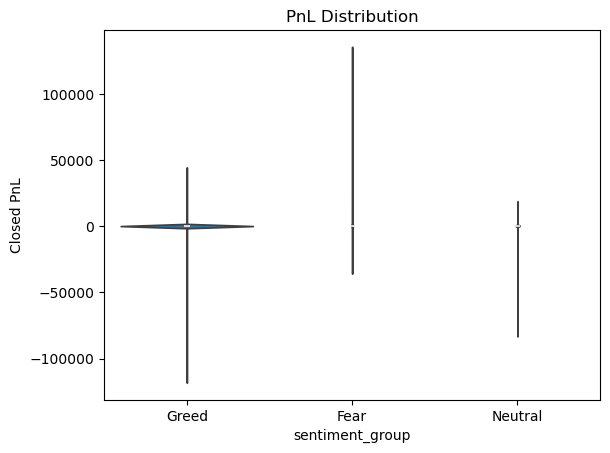

,classification,is_long
0,Extreme Greed,0.539213
1,Fear,0.556222
2,Greed,0.291989
3,Neutral,0.252906


In [138]:
#chart1
sns.boxplot(data=merged,x="sentiment_group",y="Size USD")
plt.title("Position Size by Sentiment")
plt.show()

#Chart2
sns.boxplot(data=merged,x="sentiment_group",y="leverage_proxy")
plt.title("Leverage by Sentiment")
plt.show()

#Chart3
sns.violinplot(data=merged,x="sentiment_group",y="Closed PnL")
plt.title("PnL Distribution")
plt.show()

merged["is_long"] = (merged["Direction"].str.upper().str.contains("LONG", na=False)).astype(int)
long_short = (merged.groupby("classification")["is_long"].mean().reset_index())
long_short

In [139]:
trader_leverage = ( merged.groupby("Account")["leverage_proxy"].mean().reset_index())

median_lev = trader_leverage["leverage_proxy"].median()
trader_leverage["segment"] = np.where(trader_leverage["leverage_proxy"] >= median_lev,"High Leverage","Low Leverage")

segment_perf = (merged.merge(trader_leverage[["Account","segment"]],on="Account").groupby("segment").agg( pnl=("Closed PnL","mean"),win_rate=("win","mean")))

segment_perf

,pnl,win_rate
segment,,
High Leverage,27.290069,0.406809
Low Leverage,73.645575,0.416435


In [140]:
trade_count = (merged.groupby("Account").size().reset_index(name="trade_count"))

median_trade = trade_count["trade_count"].median()
trade_count["segment"] = np.where(trade_count["trade_count"] >= median_trade,"Frequent","Infrequent")

freq_perf = (merged.merge(trade_count[["Account","segment"]],on="Account").groupby("segment").agg(pnl=("Closed PnL","mean"),win_rate=("win","mean")))

freq_perf

,pnl,win_rate
segment,,
Frequent,42.493421,0.415438
Infrequent,96.943024,0.379116


In [141]:
daily_trader = (merged.groupby(["Account","date"])["Closed PnL"].sum().reset_index())

daily_trader["win_day"] = (daily_trader["Closed PnL"] > 0).astype(int)
consistency = (daily_trader.groupby("Account")["win_day"].mean().reset_index())

consistency["segment"] = np.where(consistency["win_day"] >= 0.60,"Consistent Winner","Inconsistent")

winner_perf = (merged.merge( consistency[["Account","segment"]],on="Account").groupby("segment").agg(pnl=("Closed PnL","mean"),win_rate=("win","mean")))
winner_perf

,pnl,win_rate
segment,,
Consistent Winner,49.598629,0.429352
Inconsistent,43.924845,0.308568


In [142]:
fear = merged.loc[merged["sentiment_group"]=="Fear","Closed PnL"].dropna()
greed = merged.loc[ merged["sentiment_group"]=="Greed","Closed PnL"].dropna()

t_stat, p_value = stats.ttest_ind(fear,greed,equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -4.9038309651960725
P-value: 9.421142077044365e-07


In [143]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

merged["profitable"] = (merged["Closed PnL"] > 0).astype(int)

features = ["Size USD","leverage_proxy","value"]

X = merged[features].fillna(0)
y = merged["profitable"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74     24802
           1       0.63      0.55      0.59     17443

    accuracy                           0.68     42245
   macro avg       0.67      0.66      0.66     42245
weighted avg       0.68      0.68      0.68     42245

